In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
file=pd.read_csv("spam.csv", encoding="latin-1")
#now creating a data frame
df=pd.DataFrame(file)
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [37]:
#now removing the duplicate and empty_one
df.drop_duplicates()
df.dropna()



,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""
5048,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""


In [52]:
print("Available columns:", df.columns.tolist())

# Ensure we have two columns: 'label' and 'message'
df = pd.DataFrame({
    'label': df['label'] if 'label' in df.columns else df.iloc[:, 0],
    'message': df.iloc[:, 1:].astype(str).agg(' '.join, axis=1)  # join multiple text cols if present
})

# Split features and target
X = df['message']
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Available columns: ['label', 'message']
Features shape: (5572,)
Target shape: (5572,)


0    Go until jurong point, crazy.. Available only ...
1            Ok lar... Joking wif u oni... nan nan nan
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object

In [45]:
y.head()

0     ham
1     ham
2    spam
3     ham
4     ham
Name: label, dtype: object

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
x = tfidf.fit_transform(X)
print("TF-IDF matrix shape:", x.shape)


TF-IDF matrix shape: (5572, 8760)


In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
x = tfidf.fit_transform(X)

print(tfidf.get_feature_names_out())
print(x.toarray())


['00' '000' '000pes' ... 'ûïharry' 'ûò' 'ûówell']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [60]:
model=MultinomialNB()
model.fit(x,y)
y_pred = model.predict(x)


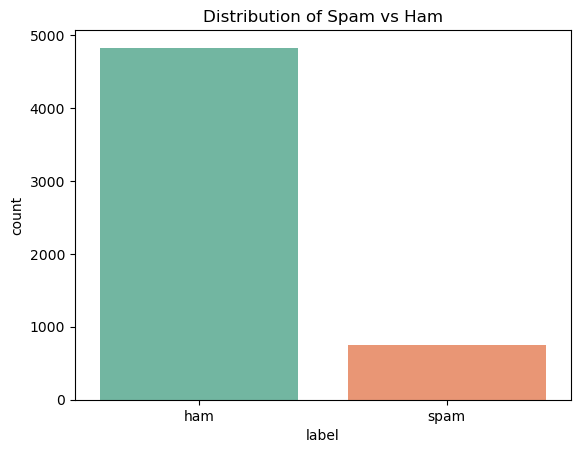

In [40]:
# making count plot
sns.countplot(x='label', hue='label', data=df, palette='Set2', legend=False)
plt.title("Distribution of Spam vs Ham")
plt.show()

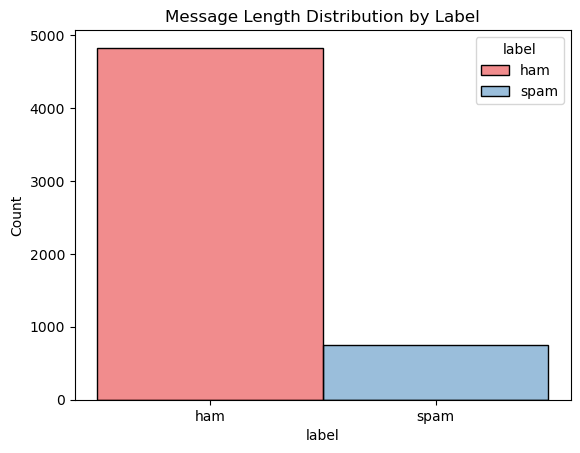

In [41]:
#histogram
sns.histplot(data=df, x='label', hue='label', bins=50, kde=True, palette='Set1')
plt.title("Message Length Distribution by Label")
plt.show()

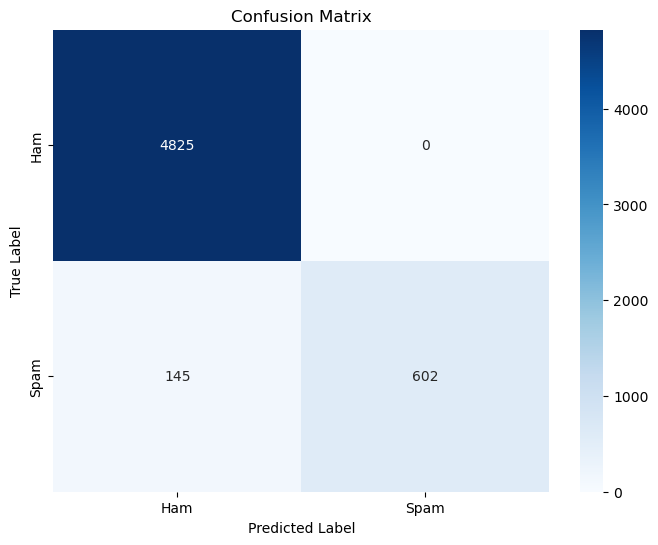

In [64]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [55]:

accuracy = accuracy_score(y, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%\n")
print("Classification Report:")
print(classification_report(y, y_pred, target_names=["Ham", "Spam"]))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

Accuracy: 97.40%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99      4825
        Spam       1.00      0.81      0.89       747

    accuracy                           0.97      5572
   macro avg       0.99      0.90      0.94      5572
weighted avg       0.97      0.97      0.97      5572

Confusion Matrix:
[[4825    0]
 [ 145  602]]
